In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

## Loading the Amazon UK Price dataset and preparing the data

In [2]:
df = pd.read_csv("amz_uk_price_prediction_dataset.csv")
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [3]:
# Filtering out columns in the dataframe where more than 80% of the values are missing
df = df[df.columns[df.isnull().mean() < 0.8]]

In [7]:
# Removing the "Id" column from the dataframe
df.drop("uid", inplace=True, axis=1)

In [8]:
df.select_dtypes("number").nunique()

stars                   42
reviews              19446
price                82916
boughtInLastMonth       25
dtype: int64

In [9]:
# Identify numerical columns that could be treated as categorical.
# We check how many unique values each numeric column has.
# If a column has fewer unique values than the chosen threshold (< 20),
# it can be considered discrete and potentially categorical.

num_cols = df.select_dtypes("number")
unique_counts = num_cols.nunique()

potential_categorical_from_numerical = num_cols.loc[:, unique_counts < 20]
potential_categorical_from_numerical

# In the Amazon dataset, all numeric columns have more than 20 unique values,
# so none of them qualify as discrete. This step returns an empty DataFrame.

""
0
1
2
3
4
...
2443646
2443647
2443648
2443649


In [10]:
# Extracting columns with object (typically string) data types to create a categorical dataframe
# For demonstration purposes, let's consider the columns in potential_categorical_from_numerical as categorical variables.
df_categorical = pd.concat([df.select_dtypes("object"), potential_categorical_from_numerical], axis=1)

# Adjusting the numerical dataframe by removing the moved columns
df_numerical = df.select_dtypes("number").drop(columns=potential_categorical_from_numerical.columns)

In [14]:
# 'isBestSeller'  exists in the original df, but pandas treats boolean as numeric, so it was not included in df_categorical.
# To use it in bivariate analysis, let´s add it manually to df_categorical

df_categorical["isBestSeller"] = df["isBestSeller"]

In [15]:
df_categorical

,asin,title,category,isBestSeller
0,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",Hi-Fi Speakers,False
1,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",Hi-Fi Speakers,True
2,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",Hi-Fi Speakers,False
3,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",Hi-Fi Speakers,False
4,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,Hi-Fi Speakers,False
...,...,...,...,...
2443646,B0CHSD7P2Q,"Motorbike Armour, Motorbike Clothing, Cycling ...",Motorbike Clothing,False
2443647,B0B7B8FNBQ,PROFIRST Waterproof Motorcycle 2 Piece Ladies ...,Motorbike Clothing,False
2443648,B0BD5FL5FB,Men’s Motorcycle Motorbike Biker Trousers Kevl...,Motorbike Clothing,False
2443649,B008OYLL4I,Texpeed Mens Motorcycle Motorbike Biker Trouse...,Motorbike Clothing,False


In [12]:
df_numerical

,stars,reviews,price,boughtInLastMonth
0,4.7,15308,21.99,0
1,4.7,98099,23.99,0
2,4.7,15308,21.99,0
3,4.7,7205,31.99,0
4,4.6,1881,17.99,0
...,...,...,...,...
2443646,0.0,0,22.34,0
2443647,0.0,0,97.99,0
2443648,0.0,0,52.99,0
2443649,4.3,404,79.99,0


## Part 1: Analyzing Best-Seller Trends Across Product Categories
Objective: Understand the relationship between product categories and their best-seller status.

In [16]:
# 1.1 -- Crosstab Analysis: Create a crosstab between the product category and the isBestSeller status.
# Are there categories where being a best-seller is more prevalent?
# Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion 
# in descending order.

# Category × Category
crosstab = pd.crosstab(df["category"], df["isBestSeller"])
crosstab

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
...,...,...
Wind Instruments,243,7
Window Treatments,234,5
Women,17559,213


In [18]:
# 1.2 -- Statistical Tests:
# Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
# Compute Cramér's V to understand the strength of association between best-seller status and category.

from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(crosstab)
p

alpha = 0.05

if p < alpha:
    print("Reject H0: Best-seller status depends on product category.")
else:
    print("Fail to reject H0: No evidence that best-seller status depends on category.")

Reject H0: Best-seller status depends on product category.


In [19]:
# Compute Cramér's V to understand the strength of association between best-seller status and category.

# Interpretation Guideline:
# 0.00–0.10 → very weak
# 0.10–0.30 → weak
# 0.30–0.50 → moderate
# > 0.50 → strong

n = crosstab.sum().sum()  # total observations
cramers_v = np.sqrt(chi2 / (n * (min(crosstab.shape) - 1)))
cramers_v

# 0.10–0.30 → weak

np.float64(0.1222829439760564)

In [ ]:
# Interpretation:
# The Chi-square test rejects H0, meaning that with such a large dataset,
# even very small differences in best-seller distribution across categories
# become statistically significant.
# However, Cramér’s V = 0.12 indicates that the strength of this association
# is weak.
# Conclusion: There is a statistically detectable relationship, but it is not
# practically meaningful. Category does not strongly influence best-seller status.

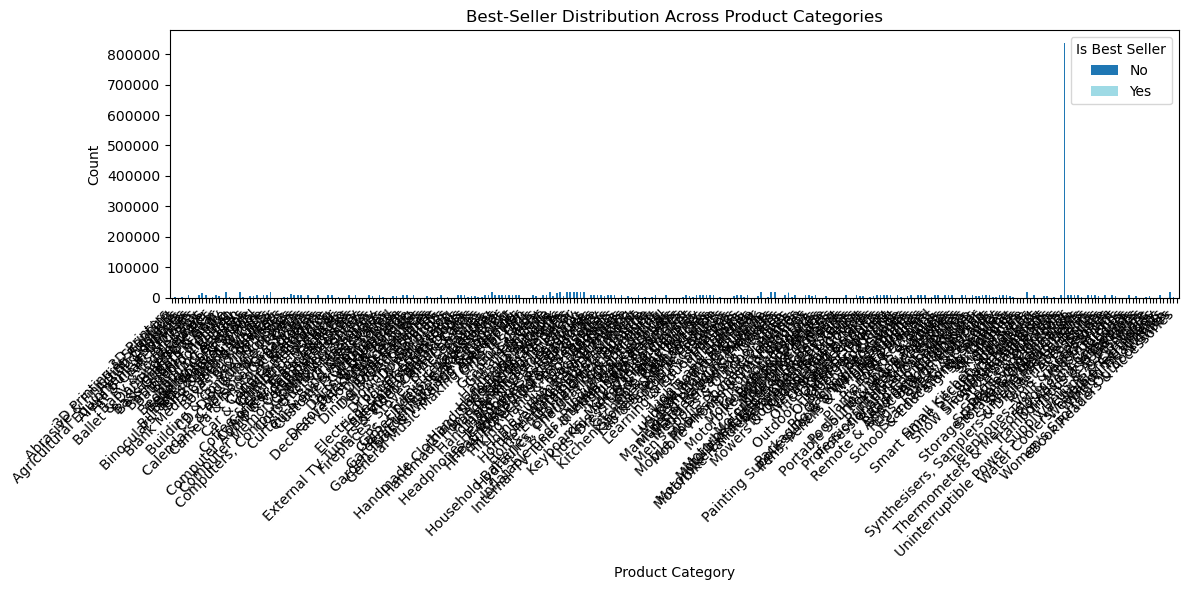

In [20]:
# 1.3 -- Visualizations:
# Visualize the relationship between product categories and the best-seller status using a stacked bar chart.
# Objective: Visualize how best-seller status is distributed across product categories.
# A stacked bar chart helps compare the proportion of best-sellers vs non-best-sellers within each category.

crosstab.plot(kind="bar", stacked=True, figsize=(12, 6), colormap="tab20")

plt.title("Best-Seller Distribution Across Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Count")
plt.legend(title="Is Best Seller", labels=["No", "Yes"])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Part 2: Exploring Product Prices and Ratings Across Categories and Brands
Objective: Investigate how different product categories influence product prices.

In [ ]:
# Preliminary Step: Remove outliers in product prices.

# For this purpose, we can use the IQR (Interquartile Range) method. Products priced below the first quartile minus 1.5 times the IQR 
# or above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset. 
# The next steps will be done with the dataframe without outliers.

# Hint: you can check the last Check For Understanding at the end of the lesson EDA Bivariate Analysis for a hint on how to do this.

In [21]:
# Calculate quartiles
Q1 = df_numerical["price"].quantile(0.25)
Q3 = df_numerical["price"].quantile(0.75)
IQR = Q3 - Q1

# Define boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
df_no_outliers = df[(df_numerical["price"] >= lower_bound) & (df_numerical["price"] <= upper_bound)]

df_no_outliers.shape

(2115963, 8)

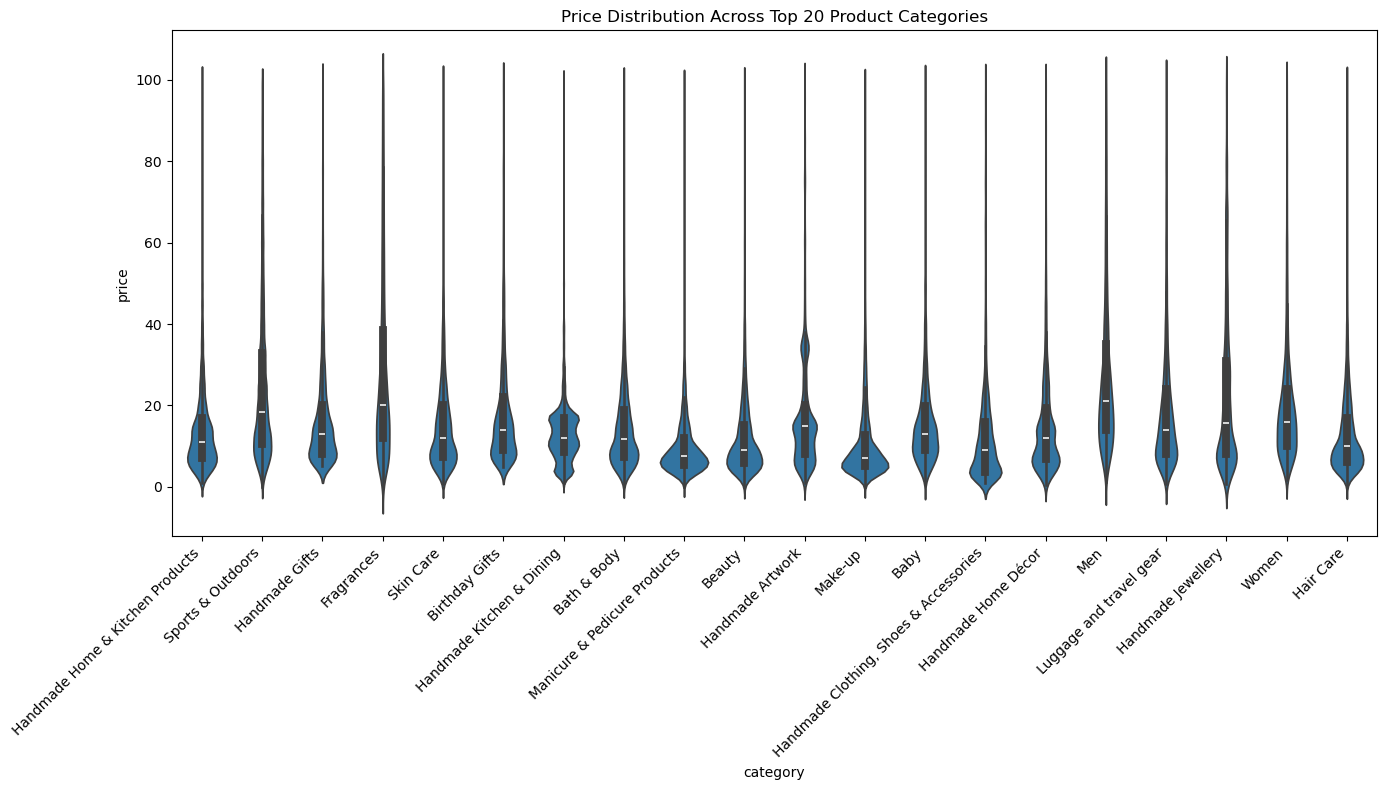

In [22]:
# 2.1 -- Violin Plots:
# Use a violin plot to visualize the distribution of price across different product categories. 
# Filter out the top 20 categories based on count for better visualization.
# Which product category tends to have the highest median price? Don't filter here by top categories.

# Top 20 categories by count
top20 = df_no_outliers["category"].value_counts().head(20).index

df_top20 = df_no_outliers[df_no_outliers["category"].isin(top20)]

plt.figure(figsize=(14, 8))
sns.violinplot(data=df_top20, x="category", y="price")
plt.xticks(rotation=45, ha="right")
plt.title("Price Distribution Across Top 20 Product Categories")
plt.tight_layout()
plt.show()

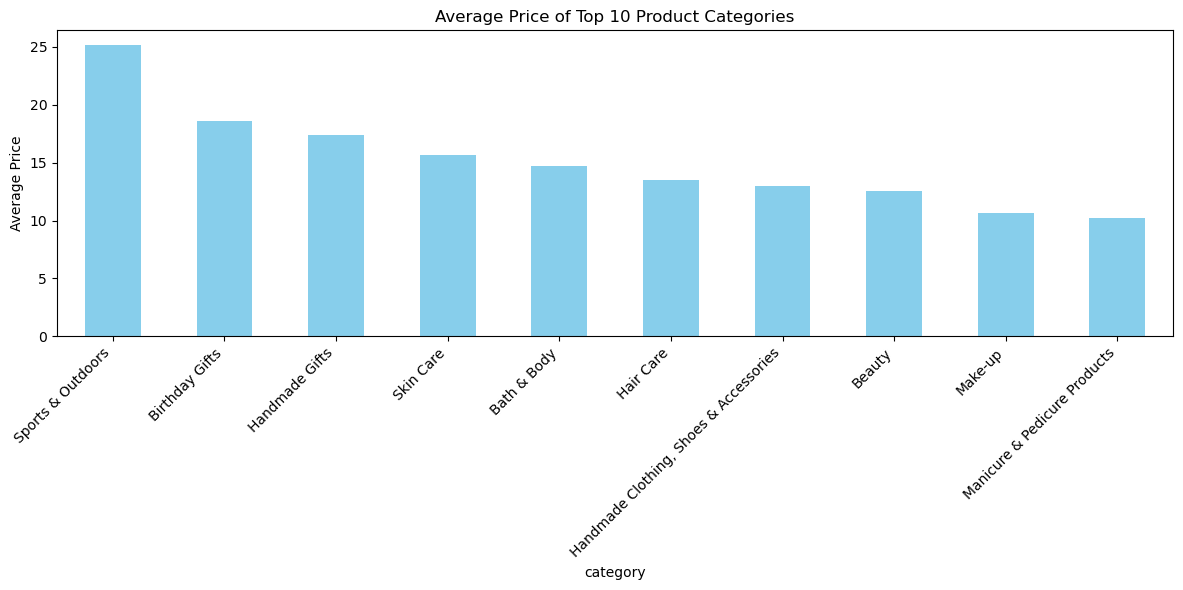

In [23]:
# 2.2 -- Bar Charts:
# Create a bar chart comparing the average price of products for the top 10 product categories (based on count).
# Which product category commands the highest average price? Don't filter here by top categories.

top10 = df_no_outliers["category"].value_counts().head(10).index

avg_price = df_no_outliers[df_no_outliers["category"].isin(top10)] \
                .groupby("category")["price"].mean() \
                .sort_values(ascending=False)

plt.figure(figsize=(12, 6))
avg_price.plot(kind="bar", color="skyblue")
plt.title("Average Price of Top 10 Product Categories")
plt.ylabel("Average Price")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

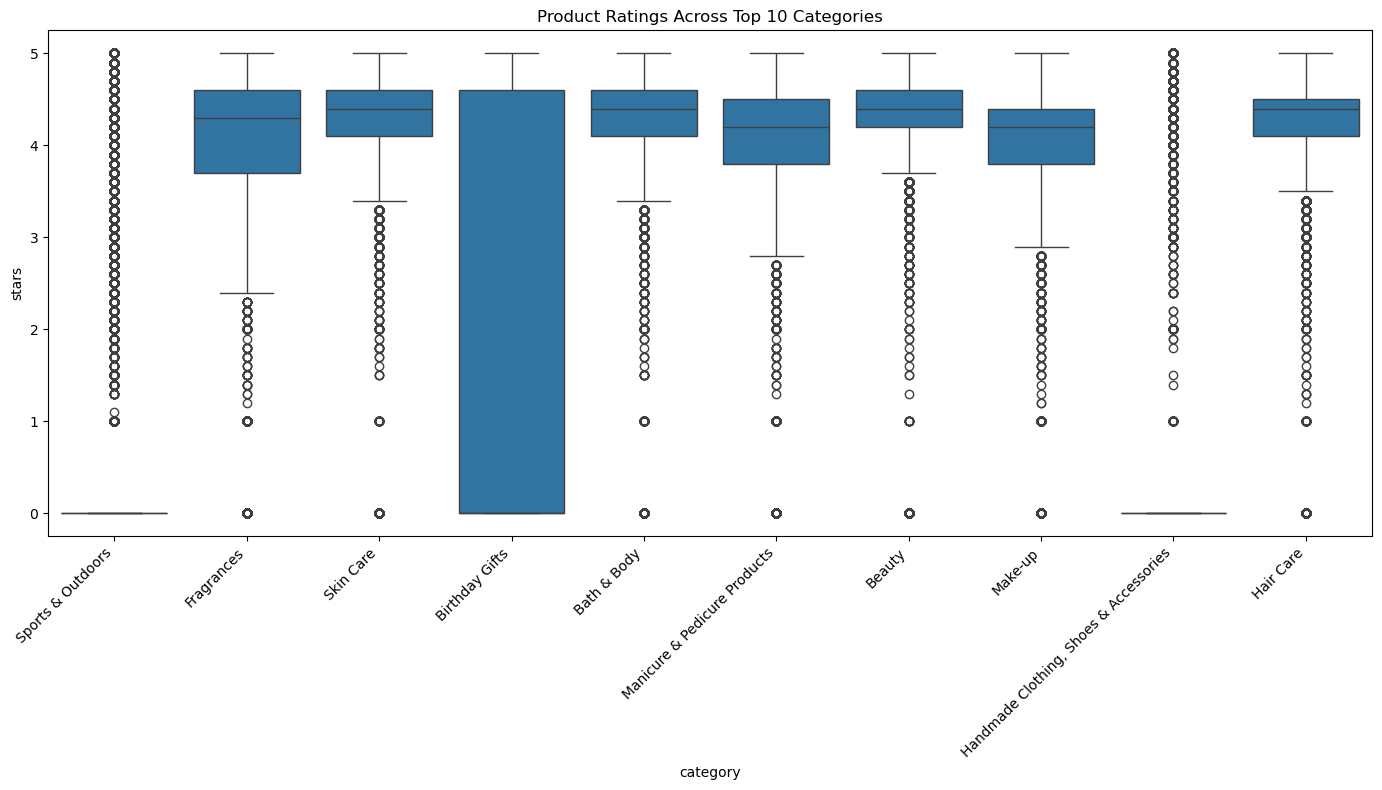

In [24]:
# 2.3 -- Box Plots:
# Visualize the distribution of product ratings based on their category using side-by-side box plots. 
# Filter out the top 10 categories based on count for better visualization.
# Which category tends to receive the highest median rating from customers? Don't filter here by top categories.

top10 = df["category"].value_counts().head(10).index
df_top10 = df[df["category"].isin(top10)]

plt.figure(figsize=(14, 8))
sns.boxplot(data=df_top10, x="category", y="stars")
plt.xticks(rotation=45, ha="right")
plt.title("Product Ratings Across Top 10 Categories")
plt.tight_layout()
plt.show()


## Part 3: Investigating the Interplay Between Product Prices and Ratings
Objective: Analyze how product ratings (stars) correlate with product prices.

In [25]:
# 3.1 -- Correlation Coefficients:
# Calculate the correlation coefficient between price and stars.
# Is there a significant correlation between product price and its rating?

# Interpretation:
# If the correlation is close to 0 → price and rating are not related.
# If positive → higher ratings tend to be associated with higher prices.
# If negative → higher ratings tend to be associated with lower prices.

corr = df_no_outliers["price"].corr(df_no_outliers["stars"])
corr

# Negative result → higher ratings tend to be associated with lower prices.

np.float64(-0.0776729987818137)

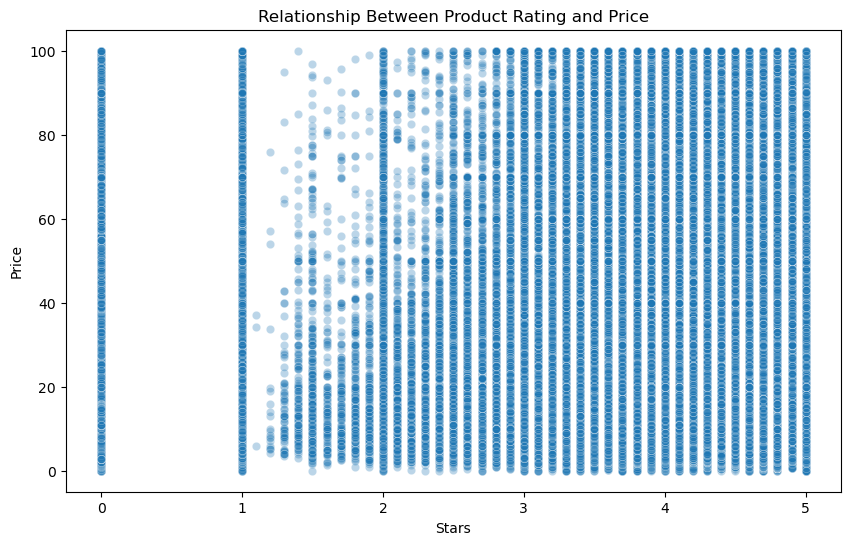

In [26]:
# 3.2 -- Visualizations:

# Scatter plot shows the relationship between product price and rating.
# Each point is a product. Patterns reveal whether higher-rated products cost more.

# Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?

plt.figure(figsize=(10,6))
sns.scatterplot(data=df_no_outliers, x="stars", y="price", alpha=0.3)
plt.title("Relationship Between Product Rating and Price")
plt.xlabel("Stars")
plt.ylabel("Price")
plt.show()

# Interpretation:
# If points form a clear upward trend → positive correlation.
# If points are scattered randomly → no correlation.

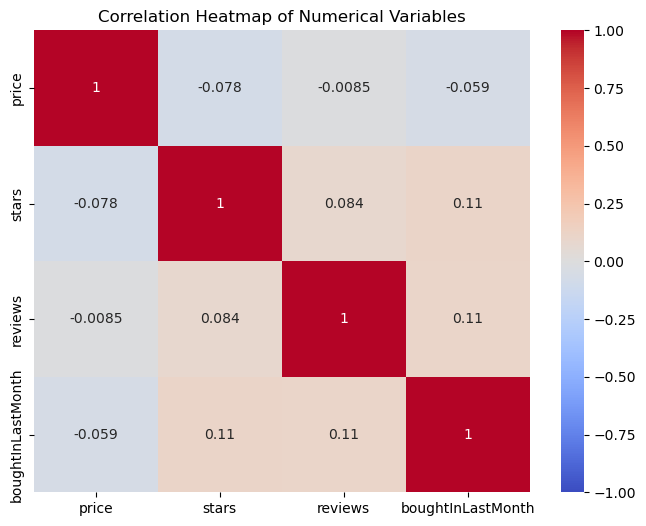

In [27]:
# Heatmap shows correlations between all numerical variables.
# Helps identify which variables move together.

# Use a correlation heatmap to visualize correlations between all numerical variables.

plt.figure(figsize=(8,6))
sns.heatmap(df_no_outliers[["price","stars","reviews","boughtInLastMonth"]].corr(),
            annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

# Interpretation:
# Dark red → strong positive correlation.
# Dark blue → strong negative correlation.
# Light colors → weak or no correlation.

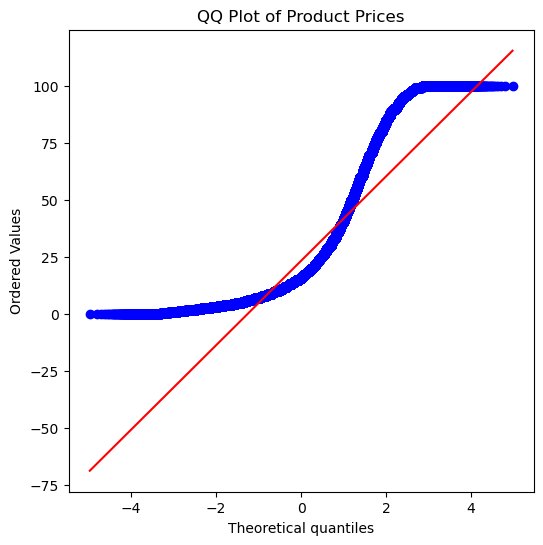

In [29]:
# QQ plot checks whether product prices follow a normal distribution.
# If points follow the diagonal line → distribution is close to normal.

# Examine if product prices typically follow a normal distribution using a QQ plot.

import scipy.stats as stats

plt.figure(figsize=(6,6))
stats.probplot(df_no_outliers["price"], dist="norm", plot=plt)
plt.title("QQ Plot of Product Prices")
plt.show()

# Interpretation:
# If points deviate strongly from the line → prices are not normally distributed.
# Amazon price data usually shows heavy tails and skewness.